# SVM HIV Classification with 5-Fold CV

This notebook evaluates the SVM model on the HIV dataset using Morgan fingerprints, stratified 5-fold cross-validation, fold-level validation/test splits, and summary statistics (mean, std, variance).

In [1]:

# If needed in Colab:
!pip -q install rdkit

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem
RDLogger.DisableLog('rdApp.*')

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import StandardScaler


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 55.2 MB/s eta 0:00:00


In [2]:

SEED = 42
N_SPLITS = 5
VAL_SIZE_WITHIN_TEMP = 0.5  # temp set is split equally into val and test
RADIUS = 2
N_BITS = 2048

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(SEED)

def smiles_to_morgan_fp(smiles_list, radius=2, n_bits=2048):
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
            fps.append(np.array(fp, dtype=np.float32))
        else:
            fps.append(np.zeros(n_bits, dtype=np.float32))
    return np.array(fps, dtype=np.float32)

def build_model(random_state):
    from sklearn.svm import SVC
    return SVC(
        kernel='rbf',
        probability=True,
        random_state=random_state
    )

def maybe_scale(X_train, X_val, X_test):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    return X_train, X_val, X_test


def evaluate_fold(model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score)
    }, y_score


In [3]:

df = pd.read_csv("https://raw.githubusercontent.com/McahitKutsal/hivcsv/main/HIV7.csv")
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

X = smiles_to_morgan_fp(df["smiles"], radius=RADIUS, n_bits=N_BITS)
y = df["HIV_active"].astype(int).values

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_results = []
roc_curves = []

for fold, (train_idx, temp_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n===== FOLD {fold} / {N_SPLITS} =====")
    set_seed(SEED + fold)

    X_train_full, y_train_full = X[train_idx], y[train_idx]
    X_temp, y_temp = X[temp_idx], y[temp_idx]

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=VAL_SIZE_WITHIN_TEMP,
        stratify=y_temp,
        random_state=SEED + fold
    )

    X_train, X_val, X_test = maybe_scale(X_train_full, X_val, X_test)

    model = build_model(random_state=SEED + fold)
    model.fit(X_train, y_train_full)

    metrics, y_score = evaluate_fold(model, X_test, y_test)
    fold_results.append({
        "fold": fold,
        "test_accuracy": metrics["accuracy"],
        "test_precision": metrics["precision"],
        "test_recall": metrics["recall"],
        "test_f1": metrics["f1"],
        "test_roc_auc": metrics["roc_auc"]
    })

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_curves.append((fold, fpr, tpr, metrics["roc_auc"]))

    print({k: round(v, 4) if isinstance(v, float) else v for k, v in fold_results[-1].items()})

results_df = pd.DataFrame(fold_results)
results_df



===== FOLD 1 / 5 =====
{'fold': 1, 'test_accuracy': 0.8754, 'test_precision': 0.9051, 'test_recall': 0.8435, 'test_f1': 0.8732, 'test_roc_auc': np.float64(0.9361)}

===== FOLD 2 / 5 =====
{'fold': 2, 'test_accuracy': 0.8581, 'test_precision': 0.8786, 'test_recall': 0.8367, 'test_f1': 0.8571, 'test_roc_auc': np.float64(0.9091)}

===== FOLD 3 / 5 =====
{'fold': 3, 'test_accuracy': 0.8443, 'test_precision': 0.8759, 'test_recall': 0.8108, 'test_f1': 0.8421, 'test_roc_auc': np.float64(0.8905)}

===== FOLD 4 / 5 =====
{'fold': 4, 'test_accuracy': 0.8858, 'test_precision': 0.9078, 'test_recall': 0.8649, 'test_f1': 0.8858, 'test_roc_auc': np.float64(0.9282)}

===== FOLD 5 / 5 =====
{'fold': 5, 'test_accuracy': 0.8374, 'test_precision': 0.8633, 'test_recall': 0.8108, 'test_f1': 0.8362, 'test_roc_auc': np.float64(0.9123)}


,fold,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,1,0.875433,0.905109,0.843537,0.873239,0.936117
1,2,0.858131,0.878571,0.836735,0.857143,0.909121
2,3,0.844291,0.875912,0.810811,0.842105,0.890502
3,4,0.885813,0.907801,0.864865,0.885813,0.928215
4,5,0.837370,0.863309,0.810811,0.836237,0.912306


In [4]:

summary_rows = []
for metric in ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"]:
    mean_val = results_df[metric].mean()
    std_val = results_df[metric].std(ddof=1)
    var_val = results_df[metric].var(ddof=1)
    summary_rows.append({
        "Metric": metric.replace("test_", "").upper(),
        "Mean": mean_val,
        "Std": std_val,
        "Variance": var_val,
        "Formatted": f"{mean_val:.4f} ± {std_val:.4f}"
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Metric,Mean,Std,Variance,Formatted
0,ACCURACY,0.860208,0.020412,0.000417,0.8602 ± 0.0204
1,PRECISION,0.886141,0.019443,0.000378,0.8861 ± 0.0194
2,RECALL,0.833352,0.023046,0.000531,0.8334 ± 0.0230
3,F1,0.858908,0.020789,0.000432,0.8589 ± 0.0208
4,ROC_AUC,0.915252,0.017764,0.000316,0.9153 ± 0.0178


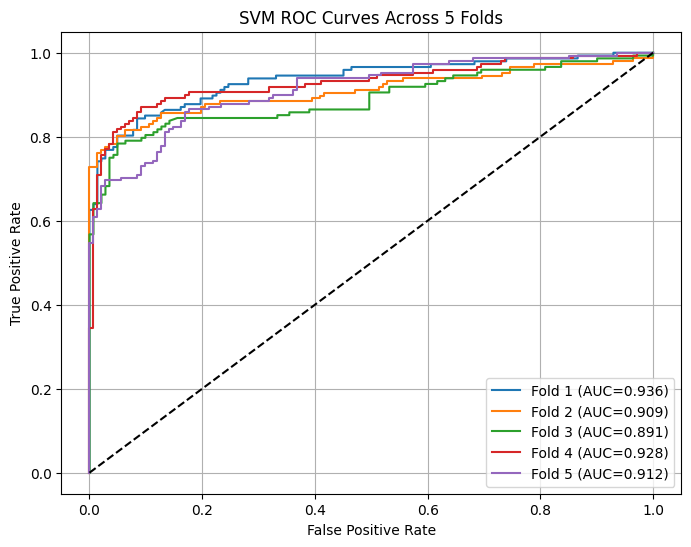

In [5]:

plt.figure(figsize=(8, 6))
for fold, fpr, tpr, auc_val in roc_curves:
    plt.plot(fpr, tpr, label=f"Fold {fold} (AUC={auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curves Across 5 Folds")
plt.legend()
plt.grid(True)
plt.show()


In [6]:

results_df.to_csv("SVM_fold_results.csv", index=False)
summary_df.to_csv("SVM_summary_results.csv", index=False)

print("Saved:")
print("- SVM_fold_results.csv")
print("- SVM_summary_results.csv")


Saved:
- SVM_fold_results.csv
- SVM_summary_results.csv


Saved: SVM_oof_predictions.csv


,fold,smiles,y_true,y_pred,y_prob
0,1,Cc1cc(S(=O)(=O)Nc2nnc3cnc4ccccc4n23)c(S)cc1Cl,1,1,0.967360
1,1,CN1C(=S)N2CCCCCCCC2C(C#N)=C1N,0,0,0.422741
2,1,O=S(=O)(SCCO)c1ccccc1,0,0,0.358121
3,1,OC1C#CCSCC#CC=C1,0,0,0.474479
4,1,O=C(O)CCSCc1cc(C(=O)Nc2ccc(C=Cc3ccc(NC(=O)c4cc...,1,1,0.967532


Saved: SVM_top_50_candidates.csv  |  Top rows: 50


,fold,smiles,y_true,y_pred,y_prob
0,3,O=C(Nc1ccc(C=Cc2ccc(NC(=O)c3ccc(N=Nc4cc(S(=O)(...,1,1,0.999998
1,2,O=C(Nc1ccc(S(=O)(=O)c2ccc(NC(=O)c3ccc(N=Nc4cc(...,1,1,0.997442
2,1,CC(=O)NS(=O)(=O)c1ccc(NC(=O)c2ccccc2SSc2ccccc2...,1,1,0.997266
3,3,Cc1cc(NC(=O)c2ccc(NC(=O)c3ccccc3)cc2)ccc1N=Nc1...,1,1,0.996861
4,1,O=C(O)c1ccc(C=Cc2ccc(N=Nc3cc(S(=O)(=O)O)c4cccn...,1,1,0.996849
5,1,CCCCCCCCCCCCCCCC(=O)Nc1ccn(C2CCC(COP(=O)(O)OCC...,1,1,0.996072
6,5,COC(=O)C(Cc1ccccc1)NP(=O)(O)OCC1OC(n2cc(C)c(=O...,1,1,0.995981
7,3,Cc1cn(C2CC(N=[N+]=[N-])C(COP(=O)(O)OCC3CCC(n4c...,1,1,0.995926
8,4,O=C(Nc1ccc2c(O)cc(S(=O)(=O)O)cc2c1)Nc1ccc2c(O)...,1,1,0.995896
9,4,Cc1cc(N=Nc2ccc(NC(=O)c3ccc(N)cc3)cc2C)ccc1N=Nc...,1,1,0.995754


Saved: SVM_top_50_descriptors.csv


,MW,LogP,HBD,HBA,TPSA,RotatableBonds,QED,smiles,fold,y_true,y_pred,y_prob
0,1105.068,8.03830,8,18,391.36,14,0.022081,O=C(Nc1ccc(C=Cc2ccc(NC(=O)c3ccc(N=Nc4cc(S(=O)(...,3,1,1,0.999998
1,1143.095,6.70070,8,20,425.50,14,0.031868,O=C(Nc1ccc(S(=O)(=O)c2ccc(NC(=O)c3ccc(N=Nc4cc(...,2,1,1,0.997442
2,503.583,4.47130,2,8,135.48,8,0.261053,CC(=O)NS(=O)(=O)c1ccc(NC(=O)c2ccccc2SSc2ccccc2...,1,1,1,0.997266
3,814.858,9.83582,5,11,236.61,10,0.065127,Cc1cc(NC(=O)c2ccc(NC(=O)c3ccccc3)cc2)ccc1N=Nc1...,3,1,1,0.996861
4,543.489,4.52080,4,8,186.81,7,0.112442,O=C(O)c1ccc(C=Cc2ccc(N=Nc3cc(S(=O)(=O)O)c4cccn...,1,1,1,0.996849


Saved: SVM_docking_candidates_filtered.csv
Saved: SVM_docking_input.smi


,MW,LogP,HBD,HBA,TPSA,RotatableBonds,QED,smiles,fold,y_true,y_pred,y_prob,Lipinski_pass
0,333.319,4.01640,0,4,60.96,2,0.524895,O=[N+]([O-])c1ccc2c(c1)nc1n2C(c2c(F)cccc2F)SC1,1,1,1,0.993821,True
1,495.646,4.61862,1,7,139.15,16,0.116671,CCSCCCCCCCCCCC(=O)OCC1OC(n2cc(C)c(=O)[nH]c2=O)...,1,1,1,0.993737,True
2,486.650,4.66792,1,6,90.39,16,0.269787,CCSCCCCCCCCCCCC(=O)OCC1OC(n2cc(C)c(=O)[nH]c2=O...,1,1,1,0.993177,True
3,263.274,2.42760,0,4,77.28,3,0.629033,O=[N+]([O-])c1ccccc1S(=O)(=O)c1ccccc1,5,1,1,0.991577,True
4,352.799,3.43910,1,5,89.31,3,0.674714,O=[N+]([O-])c1ccccc1S(=O)(=O)c1cc(Cl)cc2c1NCCC2,2,1,1,0.991311,True
5,407.455,4.16549,2,6,113.91,4,0.495645,Cc1nn(C(=O)Cc2ccccc2)c2c1C(c1ccccc1[N+](=O)[O-...,4,1,1,0.990330,True
6,336.844,4.78792,1,4,46.76,5,0.484283,Cc1occc1C(=S)Nc1ccc(Cl)c(C=NOC(C)C)c1,5,1,1,0.989740,True
7,366.147,0.77360,2,5,127.63,3,0.330965,CC1(Br)C(=O)NC(=O)N(C2CC(F)C(CO)O2)C1N=[N+]=[N-],2,1,1,0.988978,True
8,424.566,4.07304,1,4,64.09,9,0.415380,CCc1c(Cc2cc(C)cc(C)c2)n(COCCSc2ccccc2)c(=O)[nH...,3,1,1,0.988690,True
9,306.343,2.85940,1,5,89.31,5,0.677393,CCNc1ccccc1S(=O)(=O)c1ccccc1[N+](=O)[O-],5,1,1,0.988675,True


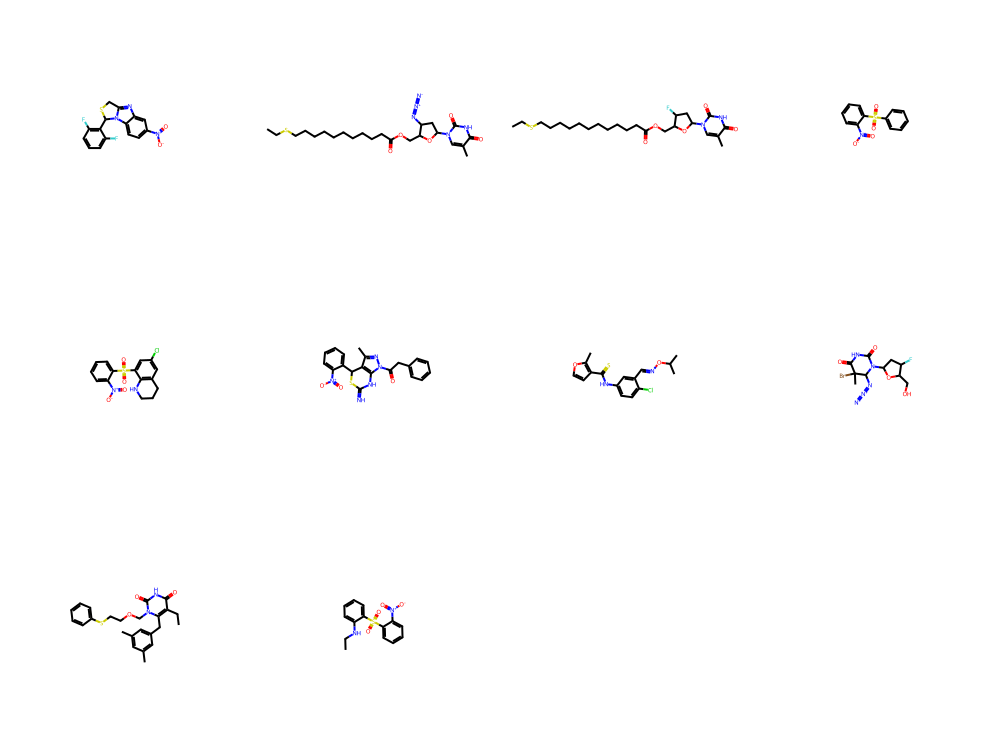


Summary
-------
Total OOF predictions          : 1445
Unique ranked molecules        : 1440
Top active candidates exported : 50
Lipinski-passing candidates    : 10
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [7]:

# =========================================================
# FINAL CANDIDATE RANKING + DOCKING PREPARATION FOR SVM
# This cell uses out-of-fold predictions to avoid score leakage.
# =========================================================

from rdkit.Chem import Descriptors, Lipinski, Crippen, QED, Draw

# ---------- 1) Out-of-fold prediction export ----------
oof_records = []

for fold, (train_idx, temp_idx) in enumerate(skf.split(X, y), start=1):
    set_seed(SEED + fold)

    X_train_full, y_train_full = X[train_idx], y[train_idx]
    X_temp, y_temp = X[temp_idx], y[temp_idx]
    smiles_temp = df.iloc[temp_idx]["smiles"].values

    X_val, X_test, y_val, y_test, smiles_val, smiles_test = train_test_split(
        X_temp, y_temp, smiles_temp,
        test_size=VAL_SIZE_WITHIN_TEMP,
        stratify=y_temp,
        random_state=SEED + fold
    )

    X_train, X_val, X_test = maybe_scale(X_train_full, X_val, X_test)

    model = build_model(random_state=SEED + fold)
    model.fit(X_train, y_train_full)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    fold_df = pd.DataFrame({
        "fold": fold,
        "smiles": smiles_test,
        "y_true": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob
    })
    oof_records.append(fold_df)

predictions_df = pd.concat(oof_records, ignore_index=True)
predictions_df.to_csv("SVM_oof_predictions.csv", index=False)

print("Saved: SVM_oof_predictions.csv")
display(predictions_df.head())


# ---------- 2) Candidate ranking ----------
# Keep unique molecules by the highest out-of-fold probability.
ranked_df = (
    predictions_df.sort_values("y_prob", ascending=False)
    .drop_duplicates(subset=["smiles"], keep="first")
    .reset_index(drop=True)
)

# Optional: prioritize molecules predicted as active
ranked_active_df = ranked_df[ranked_df["y_pred"] == 1].copy()

top_n = 50
top_candidates_df = ranked_active_df.head(top_n).copy()
top_candidates_df.to_csv("SVM_top_50_candidates.csv", index=False)

print(f"Saved: SVM_top_50_candidates.csv  |  Top rows: {len(top_candidates_df)}")
display(top_candidates_df.head(10))


# ---------- 3) RDKit descriptor calculation ----------
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    return {
        "MW": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "QED": QED.qed(mol)
    }

descriptor_rows = []
for _, row in top_candidates_df.iterrows():
    desc = compute_descriptors(row["smiles"])
    if desc is not None:
        desc.update({
            "smiles": row["smiles"],
            "fold": row["fold"],
            "y_true": row["y_true"],
            "y_pred": row["y_pred"],
            "y_prob": row["y_prob"]
        })
        descriptor_rows.append(desc)

descriptors_df = pd.DataFrame(descriptor_rows)
descriptors_df.to_csv("SVM_top_50_descriptors.csv", index=False)

print("Saved: SVM_top_50_descriptors.csv")
display(descriptors_df.head())


# ---------- 4) Lipinski filtering ----------
def lipinski_pass(row):
    return (
        row["MW"] <= 500 and
        row["LogP"] <= 5 and
        row["HBD"] <= 5 and
        row["HBA"] <= 10
    )

if not descriptors_df.empty:
    descriptors_df["Lipinski_pass"] = descriptors_df.apply(lipinski_pass, axis=1)
else:
    descriptors_df["Lipinski_pass"] = []

filtered_candidates_df = descriptors_df[descriptors_df["Lipinski_pass"] == True].copy()
filtered_candidates_df = filtered_candidates_df.sort_values("y_prob", ascending=False).reset_index(drop=True)

filtered_candidates_df.to_csv("SVM_docking_candidates_filtered.csv", index=False)
filtered_candidates_df[["smiles"]].to_csv("SVM_docking_input.smi", index=False, header=False)

print("Saved: SVM_docking_candidates_filtered.csv")
print("Saved: SVM_docking_input.smi")
display(filtered_candidates_df.head(10))


# ---------- 5) Molecule visualization ----------
top_vis = filtered_candidates_df.head(20).copy()
mols = [Chem.MolFromSmiles(sm) for sm in top_vis["smiles"] if Chem.MolFromSmiles(sm) is not None]

if len(mols) > 0:
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=4,
        subImgSize=(250, 250)
    )
    display(img)
else:
    print("No valid molecules found for visualization.")


# ---------- 6) Quick summary ----------
print("\nSummary")
print("-------")
print(f"Total OOF predictions          : {len(predictions_df)}")
print(f"Unique ranked molecules        : {len(ranked_df)}")
print(f"Top active candidates exported : {len(top_candidates_df)}")
print(f"Lipinski-passing candidates    : {len(filtered_candidates_df)}")


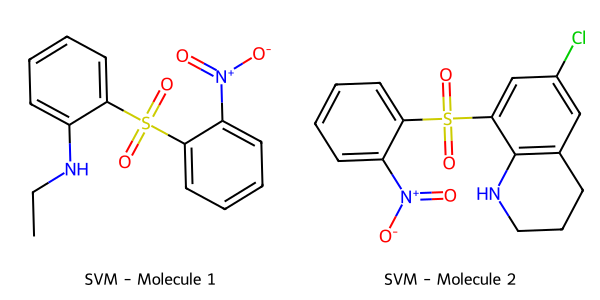

In [8]:
from rdkit import Chem
from rdkit.Chem import Draw

# Seçtiğin en iyi 2 molekül
best_smiles = [
    "CCNc1ccccc1S(=O)(=O)c1ccccc1[N+](=O)[O-]",
    "O=[N+]([O-])c1ccccc1S(=O)(=O)c1cc(Cl)cc2c1NCCC2"
]

mols = [Chem.MolFromSmiles(sm) for sm in best_smiles]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=2,
    subImgSize=(300,300),
    legends=["SVM - Molecule 1", "SVM - Molecule 2"]
)

display(img)